In [ ]:

# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the dataset
from google.colab import files
files.upload()

Saving dataset1.csv to dataset1.csv


{'dataset1.csv': b'Date,DayOfWeek,Month,Year,Is_Weekend,Is_Holiday,Product_ID,Category,Base_Price,Discount_Percentage,Current_Price,Store_ID,Store_Type,Competitor_Price,Footfall_Index,Avg_Temperature,Rainfall_mm,Social_Media_Sentiment,Lead_Time_Days,Safety_Stock_Level,Stock_On_Hand,Daily_Units_Sold\r\n4/13/2023,3,4,2023,0,0,1002,Grocery,410.09,0.01,405.99,15,Urban,411.58,127.6,29.1,8.5,0.63,7,141,471,83\r\n12/15/2023,4,12,2023,0,0,1014,Home,89.98,0.3,62.99,7,Rural,90.37,56.9,1.9,5.3,0.35,11,59,263,102\r\n9/28/2023,3,9,2023,0,0,1015,Electronics,404.88,0.14,348.2,17,Urban,408.07,191.8,14.5,2.8,0.77,4,111,302,89\r\n4/17/2023,0,4,2023,0,0,1012,Grocery,347.97,0.43,198.34,12,Urban,349.2,71.6,24.4,1.3,0.86,11,38,389,98\r\n3/13/2023,0,3,2023,0,0,1016,Grocery,280.16,0.14,240.94,18,Urban,252.64,185.5,26,0.4,0.36,14,46,262,100\r\n7/8/2023,5,7,2023,1,0,1002,Beauty,351.27,0.34,231.84,14,Urban,316.26,62.5,26.4,3.8,0.53,6,172,211,83\r\n1/21/2023,5,1,2023,1,0,1019,Clothing,208.95,0.34,137.91,15,Urban,

In [ ]:
import pandas as pd

df = pd.read_csv("dataset1.csv")
df.head()

,Date,DayOfWeek,Month,Year,Is_Weekend,Is_Holiday,Product_ID,Category,Base_Price,Discount_Percentage,...,Store_Type,Competitor_Price,Footfall_Index,Avg_Temperature,Rainfall_mm,Social_Media_Sentiment,Lead_Time_Days,Safety_Stock_Level,Stock_On_Hand,Daily_Units_Sold
0,4/13/2023,3,4,2023,0,0,1002,Grocery,410.09,0.01,...,Urban,411.58,127.6,29.1,8.5,0.63,7,141,471,83
1,12/15/2023,4,12,2023,0,0,1014,Home,89.98,0.30,...,Rural,90.37,56.9,1.9,5.3,0.35,11,59,263,102
2,9/28/2023,3,9,2023,0,0,1015,Electronics,404.88,0.14,...,Urban,408.07,191.8,14.5,2.8,0.77,4,111,302,89
3,4/17/2023,0,4,2023,0,0,1012,Grocery,347.97,0.43,...,Urban,349.20,71.6,24.4,1.3,0.86,11,38,389,98
4,3/13/2023,0,3,2023,0,0,1016,Grocery,280.16,0.14,...,Urban,252.64,185.5,26.0,0.4,0.36,14,46,262,100


In [ ]:
df.shape

(2000, 22)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    2000 non-null   object 
 1   DayOfWeek               2000 non-null   int64  
 2   Month                   2000 non-null   int64  
 3   Year                    2000 non-null   int64  
 4   Is_Weekend              2000 non-null   int64  
 5   Is_Holiday              2000 non-null   int64  
 6   Product_ID              2000 non-null   int64  
 7   Category                2000 non-null   object 
 8   Base_Price              2000 non-null   float64
 9   Discount_Percentage     2000 non-null   float64
 10  Current_Price           2000 non-null   float64
 11  Store_ID                2000 non-null   int64  
 12  Store_Type              2000 non-null   object 
 13  Competitor_Price        2000 non-null   float64
 14  Footfall_Index          2000 non-null   

In [ ]:
df.describe()

,DayOfWeek,Month,Year,Is_Weekend,Is_Holiday,Product_ID,Base_Price,Discount_Percentage,Current_Price,Store_ID,Competitor_Price,Footfall_Index,Avg_Temperature,Rainfall_mm,Social_Media_Sentiment,Lead_Time_Days,Safety_Stock_Level,Stock_On_Hand,Daily_Units_Sold
count,2000.000000,2000.000000,2000.0,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,3.029500,6.538500,2023.0,0.284500,0.093000,1009.886500,246.89615,0.248020,185.692580,10.682500,246.963605,126.598950,15.32050,5.219600,0.513395,7.779000,105.247500,252.624500,112.263000
std,1.995651,3.467208,0.0,0.451289,0.290505,5.721012,141.81454,0.141437,114.283594,5.816839,142.989116,42.488836,11.55586,5.188149,0.287879,3.940802,54.777345,146.423616,28.575726
min,0.000000,1.000000,2023.0,0.000000,0.000000,1000.000000,5.12000,0.000000,2.970000,1.000000,4.810000,50.000000,-5.00000,0.000000,0.000000,1.000000,10.000000,0.000000,17.000000
25%,1.000000,4.000000,2023.0,0.000000,0.000000,1005.000000,124.45750,0.130000,90.245000,6.000000,125.630000,91.300000,5.40000,1.500000,0.260000,5.000000,58.000000,125.000000,93.000000
50%,3.000000,7.000000,2023.0,0.000000,0.000000,1010.000000,242.50000,0.250000,173.555000,11.000000,242.070000,128.500000,15.25000,3.700000,0.520000,8.000000,106.500000,259.500000,113.000000
75%,5.000000,10.000000,2023.0,1.000000,0.000000,1015.000000,367.31750,0.370000,268.332500,16.000000,367.435000,161.750000,25.00000,7.300000,0.760000,11.000000,154.000000,379.000000,133.000000
max,6.000000,12.000000,2023.0,1.000000,1.000000,1019.000000,499.61000,0.500000,486.710000,20.000000,545.730000,199.900000,35.00000,46.100000,1.000000,14.000000,199.000000,499.000000,204.000000


In [ ]:
df.isnull().sum()

,0
Date,0
DayOfWeek,0
Month,0
Year,0
Is_Weekend,0
Is_Holiday,0
Product_ID,0
Category,0
Base_Price,0
Discount_Percentage,0


In [ ]:
import pandas as pd

df = pd.read_csv("dataset1.csv")
print(df.head())
print(df.shape)
print(df.columns)

         Date  DayOfWeek  Month  Year  Is_Weekend  Is_Holiday  Product_ID  \
0   4/13/2023          3      4  2023           0           0        1002   
1  12/15/2023          4     12  2023           0           0        1014   
2   9/28/2023          3      9  2023           0           0        1015   
3   4/17/2023          0      4  2023           0           0        1012   
4   3/13/2023          0      3  2023           0           0        1016   

      Category  Base_Price  Discount_Percentage  ...  Store_Type  \
0      Grocery      410.09                 0.01  ...       Urban   
1         Home       89.98                 0.30  ...       Rural   
2  Electronics      404.88                 0.14  ...       Urban   
3      Grocery      347.97                 0.43  ...       Urban   
4      Grocery      280.16                 0.14  ...       Urban   

   Competitor_Price Footfall_Index  Avg_Temperature  Rainfall_mm  \
0            411.58          127.6             29.1         

In [ ]:
# Convert the Date column from string format to datetime format
# This allows time-based analysis such as trends and grouping by date
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
# Verify that the Date column is now converted to datetime format
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    2000 non-null   datetime64[ns]
 1   DayOfWeek               2000 non-null   int64         
 2   Month                   2000 non-null   int64         
 3   Year                    2000 non-null   int64         
 4   Is_Weekend              2000 non-null   int64         
 5   Is_Holiday              2000 non-null   int64         
 6   Product_ID              2000 non-null   int64         
 7   Category                2000 non-null   object        
 8   Base_Price              2000 non-null   float64       
 9   Discount_Percentage     2000 non-null   float64       
 10  Current_Price           2000 non-null   float64       
 11  Store_ID                2000 non-null   int64         
 12  Store_Type              2000 non-null   object  

In [ ]:
# Check if any columns contain missing (null) values
# This is an important data cleaning step before performing analysis
df.isnull().sum()

,0
Date,0
DayOfWeek,0
Month,0
Year,0
Is_Weekend,0
Is_Holiday,0
Product_ID,0
Category,0
Base_Price,0
Discount_Percentage,0


In [ ]:
# Generate summary statistics for numerical columns
# This includes mean, standard deviation, minimum, maximum, and quartiles
df.describe()

,Date,DayOfWeek,Month,Year,Is_Weekend,Is_Holiday,Product_ID,Base_Price,Discount_Percentage,Current_Price,Store_ID,Competitor_Price,Footfall_Index,Avg_Temperature,Rainfall_mm,Social_Media_Sentiment,Lead_Time_Days,Safety_Stock_Level,Stock_On_Hand,Daily_Units_Sold
count,2000,2000.000000,2000.000000,2000.0,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2023-07-02 05:49:12.000000256,3.029500,6.538500,2023.0,0.284500,0.093000,1009.886500,246.89615,0.248020,185.692580,10.682500,246.963605,126.598950,15.32050,5.219600,0.513395,7.779000,105.247500,252.624500,112.263000
min,2023-01-01 00:00:00,0.000000,1.000000,2023.0,0.000000,0.000000,1000.000000,5.12000,0.000000,2.970000,1.000000,4.810000,50.000000,-5.00000,0.000000,0.000000,1.000000,10.000000,0.000000,17.000000
25%,2023-04-04 18:00:00,1.000000,4.000000,2023.0,0.000000,0.000000,1005.000000,124.45750,0.130000,90.245000,6.000000,125.630000,91.300000,5.40000,1.500000,0.260000,5.000000,58.000000,125.000000,93.000000
50%,2023-07-01 00:00:00,3.000000,7.000000,2023.0,0.000000,0.000000,1010.000000,242.50000,0.250000,173.555000,11.000000,242.070000,128.500000,15.25000,3.700000,0.520000,8.000000,106.500000,259.500000,113.000000
75%,2023-10-02 06:00:00,5.000000,10.000000,2023.0,1.000000,0.000000,1015.000000,367.31750,0.370000,268.332500,16.000000,367.435000,161.750000,25.00000,7.300000,0.760000,11.000000,154.000000,379.000000,133.000000
max,2023-12-31 00:00:00,6.000000,12.000000,2023.0,1.000000,1.000000,1019.000000,499.61000,0.500000,486.710000,20.000000,545.730000,199.900000,35.00000,46.100000,1.000000,14.000000,199.000000,499.000000,204.000000
std,NaN,1.995651,3.467208,0.0,0.451289,0.290505,5.721012,141.81454,0.141437,114.283594,5.816839,142.989116,42.488836,11.55586,5.188149,0.287879,3.940802,54.777345,146.423616,28.575726


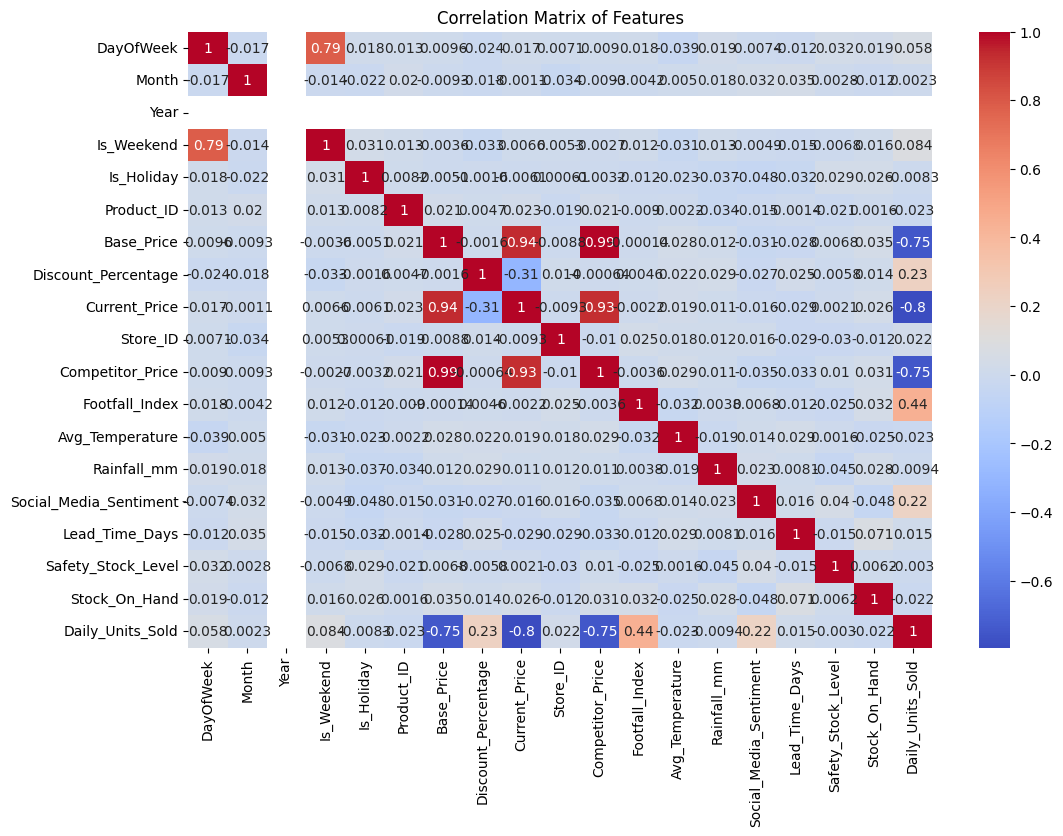

In [ ]:
# Import visualization libraries for plotting
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix for numerical features
corr = df.corr(numeric_only=True)

# Create a heatmap to visualize relationships between variables
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')

# Add title to the plot
plt.title("Correlation Matrix of Features")

# Display the heatmap
plt.show()

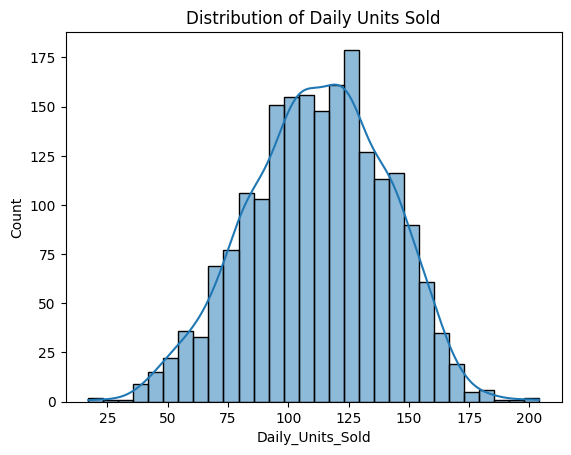

In [ ]:
# Plot the distribution of the target variable
# This helps understand how sales values are spread across the dataset

sns.histplot(df['Daily_Units_Sold'], kde=True)

# Add title to the plot
plt.title("Distribution of Daily Units Sold")

# Display the plot
plt.show()

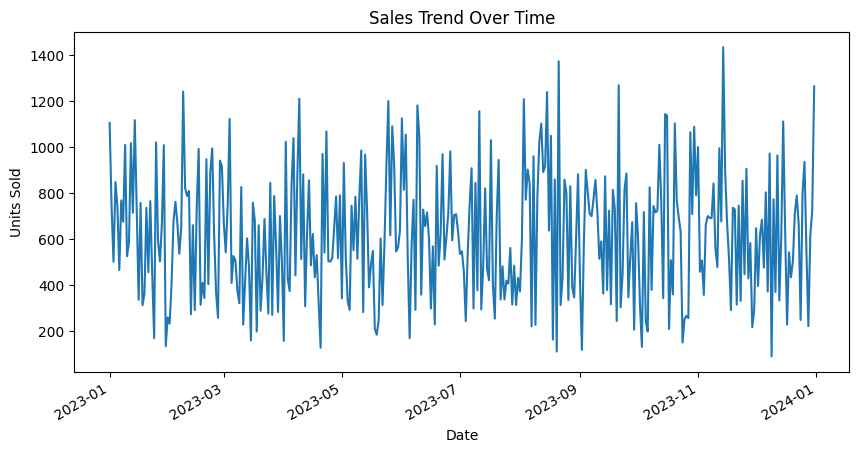

In [ ]:
# Group sales by date and calculate total units sold per day
sales_trend = df.groupby('Date')['Daily_Units_Sold'].sum()

# Plot the sales trend over time
sales_trend.plot(figsize=(10,5))

# Add labels and title
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")

# Display the plot
plt.show()

In [ ]:
# Import StandardScaler to normalize numerical features
from sklearn.preprocessing import StandardScaler

# Remove columns that should not be used for PCA
# (Date and target variable are excluded)
features = df.drop(columns=['Date', 'Daily_Units_Sold'])

# Convert categorical variables into numeric format
features = pd.get_dummies(features, drop_first=True)

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the data
scaled_features = scaler.fit_transform(features)

In [ ]:
# Import PCA from sklearn
from sklearn.decomposition import PCA

# Initialize PCA model
pca = PCA()

# Apply PCA on the scaled dataset
pca_components = pca.fit_transform(scaled_features)

In [ ]:
# Check how much variance each principal component explains
explained_variance = pca.explained_variance_ratio_

# Print first five components
print("Explained variance by first 5 components:")
print(explained_variance[:5])

Explained variance by first 5 components:
[0.13339154 0.08185988 0.06006487 0.05804271 0.05754784]


In [ ]:
# Add the first three principal components as new features in the dataset
df['PCA1'] = pca_components[:,0]
df['PCA2'] = pca_components[:,1]
df['PCA3'] = pca_components[:,2]

# Display updated dataset
df.head()

,Date,DayOfWeek,Month,Year,Is_Weekend,Is_Holiday,Product_ID,Category,Base_Price,Discount_Percentage,...,Avg_Temperature,Rainfall_mm,Social_Media_Sentiment,Lead_Time_Days,Safety_Stock_Level,Stock_On_Hand,Daily_Units_Sold,PCA1,PCA2,PCA3
0,2023-04-13,3,4,2023,0,0,1002,Grocery,410.09,0.01,...,29.1,8.5,0.63,7,141,471,83,2.498652,-0.524643,2.740321
1,2023-12-15,4,12,2023,0,0,1014,Home,89.98,0.30,...,1.9,5.3,0.35,11,59,263,102,-1.894125,-0.267543,-0.707009
2,2023-09-28,3,9,2023,0,0,1015,Electronics,404.88,0.14,...,14.5,2.8,0.77,4,111,302,89,2.271951,-0.290732,-0.987807
3,2023-04-17,0,4,2023,0,0,1012,Grocery,347.97,0.43,...,24.4,1.3,0.86,11,38,389,98,0.619418,-1.777704,1.724794
4,2023-03-13,0,3,2023,0,0,1016,Grocery,280.16,0.14,...,26.0,0.4,0.36,14,46,262,100,0.357165,-1.592279,2.118660


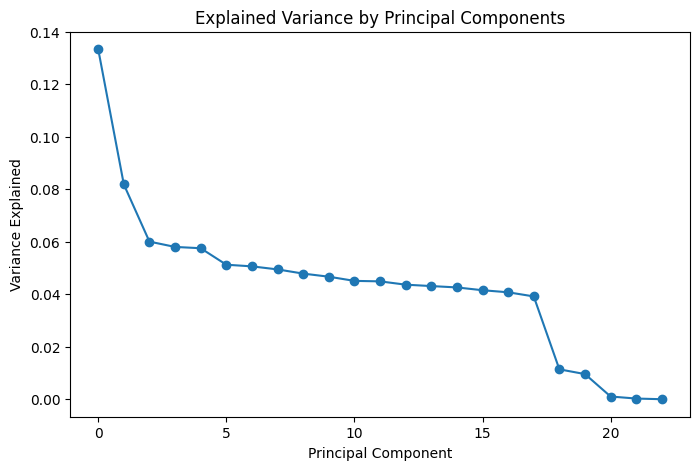

In [ ]:
# Plot explained variance of principal components
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(pca.explained_variance_ratio_, marker='o')

plt.title("Explained Variance by Principal Components")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")

plt.show()

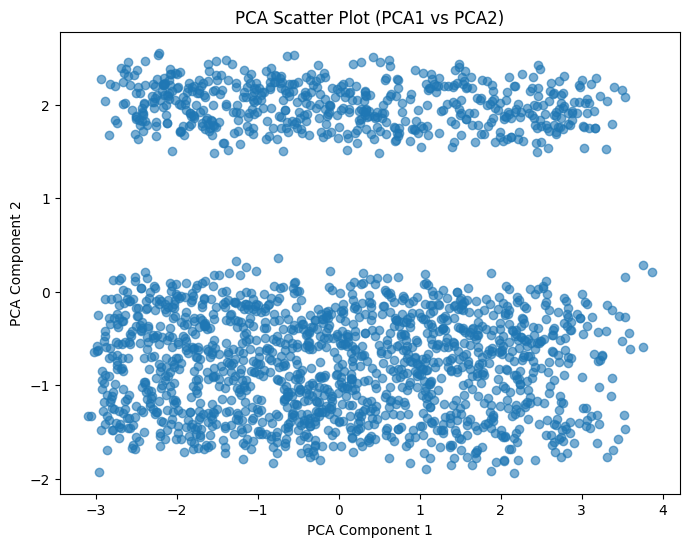

In [ ]:
# Visualize the relationship between the first two principal components

plt.figure(figsize=(8,6))

# Create a scatter plot of PCA1 vs PCA2
plt.scatter(df['PCA1'], df['PCA2'], alpha=0.6)

# Add labels and title
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Scatter Plot (PCA1 vs PCA2)")

# Display the plot
plt.show()